# Domain Adaptation of DistilBERT - PRODUCTION VERSION

This version includes:
- ✅ Advanced PDF text extraction with PyMuPDF
- ✅ **CRITICAL FIX**: Handles "anetwork" → "a network" spacing issues
- ✅ Better sentence boundary detection
- ✅ Quality validation to reject malformed chunks
- ✅ Optimized training parameters to prevent overfitting

## 1. Install Required Packages

In [1]:
!pip install transformers datasets torch PyMuPDF pandas numpy matplotlib nltk --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.1/24.1 MB 71.1 MB/s eta 0:00:00


## 2. Import Libraries

In [2]:
import fitz  # PyMuPDF
import torch
from transformers import (
    DistilBertTokenizer,
    DistilBertForMaskedLM,
    DataCollatorForLanguageModeling,
    Trainer,
    TrainingArguments,
    pipeline
)
from datasets import Dataset
import pandas as pd
import numpy as np
from pathlib import Path
import re
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Download NLTK data for better sentence splitting
import nltk
try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt', quiet=True)

# Check if GPU is available
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU: Tesla T4


## 3. Enhanced PDF Text Extraction

In [3]:
def extract_text_from_pdf(pdf_path):
    """
    Extract text from a PDF file using PyMuPDF.
    """
    text = ""
    try:
        doc = fitz.open(pdf_path)
        total_pages = len(doc)
        print(f"Processing {pdf_path}: {total_pages} pages")

        for page_num in range(total_pages):
            page = doc[page_num]
            page_text = page.get_text("text")

            if page_text:
                # Fix common PDF ligatures immediately
                page_text = page_text.replace('ﬁ', 'fi')
                page_text = page_text.replace('ﬂ', 'fl')
                page_text = page_text.replace('ﬀ', 'ff')
                page_text = page_text.replace('ﬃ', 'ffi')
                page_text = page_text.replace('ﬄ', 'ffl')

                text += page_text + "\n"

            if (page_num + 1) % 50 == 0:
                print(f"  Processed {page_num + 1}/{total_pages} pages...")

        doc.close()

    except Exception as e:
        print(f"Error reading {pdf_path}: {e}")

    return text

def clean_pdf_text(text):
    """
    Advanced cleaning of PDF-extracted text.
    FIXES: "anetwork" → "a network", "atransformer" → "a transformer", etc.
    """
    # Fix unicode quotation marks and dashes
    replacements = {
        '\u2018': "'", '\u2019': "'", '\u201c': '"', '\u201d': '"',
        '\u2013': '-', '\u2014': '-', '\u2026': '...',
        '\u00b0': ' degrees',
    }
    for old, new in replacements.items():
        text = text.replace(old, new)

    # Remove null characters and control characters
    text = re.sub(r'[\x00-\x08\x0b-\x0c\x0e-\x1f\x7f-\x9f]', '', text)

    # CRITICAL FIX: Add space after 'a' when followed by lowercase letter
    # This fixes: "anetwork" → "a network", "atransformer" → "a transformer"
    text = re.sub(r'\ba([a-z])', r'a \1', text)

    # Fix other common merged article patterns
    text = re.sub(r'\bthe([A-Z])', r'the \1', text)
    text = re.sub(r'\ban([a-z])', r'an \1', text)

    # Split into lines for processing
    lines = text.split('\n')
    cleaned_lines = []

    for line in lines:
        line = line.strip()

        # Skip very short lines (headers, footers, page numbers)
        if len(line) < 30:
            continue

        # Skip lines that are mostly numbers
        if sum(c.isdigit() for c in line) > len(line) * 0.5:
            continue

        # Skip lines that are mostly special characters (table borders, etc.)
        alpha_count = sum(c.isalpha() for c in line)
        if alpha_count < len(line) * 0.5:
            continue

        # Fix split words (only with 3+ letter second part to avoid "a fault")
        line = re.sub(r'\b([a-z])\s+([a-z]{3,})\b', r'\1\2', line)

        # Remove hyphenation at line breaks
        line = re.sub(r'(\w+)-\s+(\w+)', r'\1\2', line)

        cleaned_lines.append(line)

    # Join lines back together
    text = ' '.join(cleaned_lines)

    # Remove excessive whitespace
    text = re.sub(r'\s+', ' ', text)

    # Remove standalone special characters
    text = re.sub(r'\s[^\w\s.,;:!?\-\'\"]\s', ' ', text)

    return text.strip()

def validate_text_quality(text, sample_size=1000):
    """
    Validate the quality of extracted text.
    """
    print("\n" + "="*80)
    print("TEXT QUALITY VALIDATION")
    print("="*80)

    # Count character types
    total_chars = len(text)
    alpha_chars = sum(c.isalpha() for c in text)
    digit_chars = sum(c.isdigit() for c in text)
    space_chars = sum(c.isspace() for c in text)

    print(f"\n📊 Character Statistics:")
    print(f"   Total characters: {total_chars:,}")
    print(f"   Alphabetic: {alpha_chars:,} ({100*alpha_chars/total_chars:.1f}%)")
    print(f"   Digits: {digit_chars:,} ({100*digit_chars/total_chars:.1f}%)")
    print(f"   Whitespace: {space_chars:,} ({100*space_chars/total_chars:.1f}%)")

    # Check for PDF artifacts
    artifacts = ['ﬁ', 'ﬂ', 'ﬀ']
    found_artifacts = [a for a in artifacts if a in text]
    if found_artifacts:
        print(f"\n⚠️  Found PDF ligature artifacts: {found_artifacts}")
    else:
        print(f"\n✅ No PDF ligature artifacts")

    # Check for merged article problems
    merged_patterns = re.findall(r'\ba[a-z]{4,}\b', text[:10000])
    suspicious = [w for w in merged_patterns if w not in
                  {'about', 'above', 'after', 'again', 'against', 'allow', 'almost',
                   'alone', 'along', 'already', 'also', 'although', 'always', 'among',
                   'another', 'answer', 'appear', 'apply', 'approach', 'around'}]

    if suspicious:
        print(f"\n⚠️  Potential merged 'a+word' patterns found: {set(suspicious[:10])}")
    else:
        print(f"\n✅ No merged article patterns detected")

    # Show sample
    print(f"\n📝 Sample text (first {sample_size} chars):")
    print("-" * 80)
    print(text[:sample_size])
    print("-" * 80)

# Replace these paths with your actual PDF paths
pdf_paths = [
    "txtbook1.pdf",
    "txtbook2.pdf"
]

# Extract and clean text
print("\n" + "="*80)
print("EXTRACTING AND CLEANING TEXT FROM PDFs")
print("="*80 + "\n")

all_text = ""
for pdf_path in pdf_paths:
    if Path(pdf_path).exists():
        print(f"Extracting from {pdf_path}...")
        raw_text = extract_text_from_pdf(pdf_path)
        cleaned_text = clean_pdf_text(raw_text)
        all_text += cleaned_text + " "
        print(f"  Extracted {len(cleaned_text):,} characters (cleaned)\n")
    else:
        print(f"⚠️  File not found: {pdf_path}")

if all_text:
    validate_text_quality(all_text)
else:
    print("\n❌ No text extracted. Please check your PDF paths.")


EXTRACTING AND CLEANING TEXT FROM PDFs

Extracting from txtbook1.pdf...
Processing txtbook1.pdf: 296 pages
  Processed 50/296 pages...
  Processed 100/296 pages...
  Processed 150/296 pages...
  Processed 200/296 pages...
  Processed 250/296 pages...
  Extracted 639,022 characters (cleaned)

Extracting from txtbook2.pdf...
Processing txtbook2.pdf: 525 pages
  Processed 50/525 pages...
  Processed 100/525 pages...
  Processed 150/525 pages...
  Processed 200/525 pages...
  Processed 250/525 pages...
  Processed 300/525 pages...
  Processed 350/525 pages...
  Processed 400/525 pages...
  Processed 450/525 pages...
  Processed 500/525 pages...
  Extracted 1,031,473 characters (cleaned)


TEXT QUALITY VALIDATION

📊 Character Statistics:
   Total characters: 1,670,497
   Alphabetic: 1,347,873 (80.7%)
   Digits: 14,439 (0.9%)
   Whitespace: 264,819 (15.9%)

✅ No PDF ligature artifacts

⚠️  Potential merged 'a+word' patterns found: {'adevice', 'ashort', 'appropriate', 'arresters', 'analysis'

## 4. Advanced Sentence-Based Chunking

In [5]:
def split_into_sentences(text):
    """
    Split text into sentences using NLTK for better accuracy.
    """
    from nltk.tokenize import sent_tokenize

    # Download 'punkt_tab' if not already downloaded (as suggested by the error)
    import nltk
    try:
        nltk.data.find('tokenizers/punkt_tab')
    except LookupError:
        nltk.download('punkt_tab', quiet=True)

    sentences = sent_tokenize(text)

    # Filter sentences
    filtered = []
    for sent in sentences:
        sent = sent.strip()

        # Length requirements
        if len(sent) < 30 or len(sent) > 600:
            continue

        # Must have enough alphabetic characters
        alpha_count = sum(c.isalpha() for c in sent)
        if alpha_count < 20:
            continue

        # Skip if too many numbers (likely a table or figure caption)
        digit_count = sum(c.isdigit() for c in sent)
        if digit_count > len(sent) * 0.3:
            continue

        filtered.append(sent)

    return filtered

def create_training_chunks(text, chunk_size=3):
    """
    Create high-quality training chunks.

    Args:
        text: Cleaned text
        chunk_size: Number of sentences per chunk
    """
    sentences = split_into_sentences(text)

    chunks = []
    for i in range(0, len(sentences) - chunk_size + 1):
        chunk = ' '.join(sentences[i:i+chunk_size])

        # Quality checks
        if len(chunk) < 100:  # Too short
            continue

        # Check for incomplete sentences (ends with numbers or weird characters)
        if chunk[-1] in '0123456789-:;':
            continue

        chunks.append(chunk)

    return chunks

# Create training chunks
print("\n" + "="*80)
print("CREATING TRAINING CHUNKS")
print("="*80 + "\n")

training_chunks = create_training_chunks(all_text, chunk_size=3)

print(f"Created {len(training_chunks):,} training chunks")
print(f"Average chunk length: {np.mean([len(c) for c in training_chunks]):.0f} characters")
print(f"Median chunk length: {np.median([len(c) for c in training_chunks]):.0f} characters")

# Manual inspection
print("\n" + "="*80)
print("MANUAL QUALITY INSPECTION (10 Random Chunks)")
print("="*80 + "\n")

for i, chunk in enumerate(np.random.choice(training_chunks, min(10, len(training_chunks)), replace=False), 1):
    print(f"--- Chunk {i} ---")
    print(chunk[:300])
    if len(chunk) > 300:
        print("...")
    print("-" * 80 + "\n")


CREATING TRAINING CHUNKS

Created 12,039 training chunks
Average chunk length: 403 characters
Median chunk length: 381 characters

MANUAL QUALITY INSPECTION (10 Random Chunks)

--- Chunk 1 ---
The inductive reactance a t afrequency of 30 MHz is 500,000 times a sgreat a sthat of the same conductor when the applied voltage is a t 60 Hz. At microprocessor switching speeds (over 1 to 30 MHz), current penetration in the copper conductor is less than a t 60 Hz, with the result that the effectiv
...
--------------------------------------------------------------------------------

--- Chunk 2 ---
Listed below is a partial summary of the materials a nd products used for insulating electrical 1.7.1 Rigid Laminates Sheet, Rod, a nd Tube Canvas-based phenolic laminate Transite HT a nd NAD-11 high-temperature cement boards 1.7.2 Glass Polyester Products Glass polyester channels a nd angles Glass 
...
--------------------------------------------------------------------------------

--- Chunk 3 ---


## 5. Load Tokenizer and Model

In [6]:
print("\n" + "="*80)
print("LOADING MODEL")
print("="*80 + "\n")

model_name = "distilbert-base-uncased"
tokenizer = DistilBertTokenizer.from_pretrained(model_name)
model = DistilBertForMaskedLM.from_pretrained(model_name).to(device)

print(f"✅ Loaded {model_name}")
print(f"   Vocabulary size: {len(tokenizer):,}")
print(f"   Model parameters: {sum(p.numel() for p in model.parameters()):,}")


LOADING MODEL



tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

✅ Loaded distilbert-base-uncased
   Vocabulary size: 30,522
   Model parameters: 66,985,530


## 6. Prepare Dataset with Quality Validation

In [7]:
def tokenize_function(examples):
    """
    Tokenize with validation.
    """
    return tokenizer(
        examples["text"],
        truncation=True,
        max_length=512,
        padding="max_length",
        return_special_tokens_mask=True
    )

print("\n" + "="*80)
print("PREPARING DATASET")
print("="*80 + "\n")

# Create dataset
dataset_dict = {"text": training_chunks}
dataset = Dataset.from_dict(dataset_dict)

# Tokenize
tokenized_dataset = dataset.map(
    tokenize_function,
    batched=True,
    remove_columns=["text"]
)

# Split
split_dataset = tokenized_dataset.train_test_split(test_size=0.1, seed=42)
train_dataset = split_dataset["train"]
val_dataset = split_dataset["test"]

print(f"Training samples: {len(train_dataset):,}")
print(f"Validation samples: {len(val_dataset):,}")

# Data collator - REDUCED masking probability
data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=True,
    mlm_probability=0.10  # Reduced from 0.15 to prevent overfitting
)

print("\n✅ Dataset prepared")
print("   10% of tokens will be masked (reduced to prevent overfitting)")


PREPARING DATASET



Map:   0%|          | 0/12039 [00:00<?, ? examples/s]

Training samples: 10,835
Validation samples: 1,204

✅ Dataset prepared
   10% of tokens will be masked (reduced to prevent overfitting)


## 7. Optimized Training Configuration

In [9]:
training_args = TrainingArguments(
    output_dir="./distilbert-domain-adapted",
    num_train_epochs=5,  # Increased from 3
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    eval_strategy="steps",
    eval_steps=500,
    save_steps=1000,
    save_total_limit=2,
    learning_rate=2e-5,  # Reduced from 5e-5 to prevent overfitting
    weight_decay=0.01,
    warmup_steps=500,
    logging_dir="./logs",
    logging_steps=100,
    load_best_model_at_end=True,
    metric_for_best_model="loss",
    push_to_hub=False,
    fp16=torch.cuda.is_available(),
)

print("\n" + "="*80)
print("TRAINING CONFIGURATION (OPTIMIZED)")
print("="*80 + "\n")
print(f"Epochs: {training_args.num_train_epochs} (increased for better convergence)")
print(f"Batch size: {training_args.per_device_train_batch_size}")
print(f"Learning rate: {training_args.learning_rate} (reduced to prevent overfitting)")
print(f"Warmup steps: {training_args.warmup_steps}")
print(f"Mixed precision: {training_args.fp16}")

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.



TRAINING CONFIGURATION (OPTIMIZED)

Epochs: 5 (increased for better convergence)
Batch size: 8
Learning rate: 2e-05 (reduced to prevent overfitting)
Warmup steps: 500
Mixed precision: True


## 8. Train the Model

In [10]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=data_collator,
)

print("\n" + "="*80)
print("STARTING TRAINING")
print("="*80 + "\n")

train_result = trainer.train()

print("\n" + "="*80)
print("TRAINING COMPLETE")
print("="*80 + "\n")
print(f"Final training loss: {train_result.training_loss:.4f}")

# Save model
trainer.save_model("./distilbert-domain-adapted-final")
tokenizer.save_pretrained("./distilbert-domain-adapted-final")

print("\n✅ Model saved to ./distilbert-domain-adapted-final")


STARTING TRAINING



Step,Training Loss,Validation Loss
500,2.613348,2.476788
1000,2.285726,2.131685
1500,2.125089,1.993990
2000,2.072083,1.981004
2500,2.014164,1.863646
3000,1.923172,1.785668
3500,1.811877,1.784432
4000,1.787215,1.729168
4500,1.735306,1.735007
5000,1.703279,1.654886


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias', 'vocab_projector.weight'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].



TRAINING COMPLETE

Final training loss: 1.9789


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


✅ Model saved to ./distilbert-domain-adapted-final


## 9. Evaluate

In [11]:
print("\n" + "="*80)
print("EVALUATION")
print("="*80 + "\n")

eval_results = trainer.evaluate()

print("Validation Results:")
for key, value in eval_results.items():
    print(f"  {key}: {value:.4f}")

perplexity = np.exp(eval_results['eval_loss'])
print(f"\nPerplexity: {perplexity:.2f}")


EVALUATION



Validation Results:
  eval_loss: 1.7118
  eval_runtime: 9.3963
  eval_samples_per_second: 128.1350
  eval_steps_per_second: 16.0700
  epoch: 5.0000

Perplexity: 5.54


## 10. Load Models for Comparison

In [12]:
print("\n" + "="*80)
print("LOADING MODELS FOR COMPARISON")
print("="*80 + "\n")

fill_mask_original = pipeline(
    "fill-mask",
    model="distilbert-base-uncased",
    device=0 if torch.cuda.is_available() else -1
)

fill_mask_finetuned = pipeline(
    "fill-mask",
    model="./distilbert-domain-adapted-final",
    device=0 if torch.cuda.is_available() else -1
)

print("✅ Both models loaded")


LOADING MODELS FOR COMPARISON



Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

✅ Both models loaded


## 11. Test Sentences

In [13]:
test_sentences = [
    "The voltage [MASK] caused equipment damage.",
    "The transformer [MASK] exceeded the design limits.",
    "A fault on the distribution [MASK] requires immediate attention.",
    "The circuit breaker [MASK] to protect the system.",
    "Power system [MASK] is essential for grid stability.",
    "The relay [MASK] detected an abnormal condition.",
    "Insulation [MASK] can lead to equipment failure.",
    "The feeder [MASK] supplies power to customers.",
    "Lightning [MASK] can damage distribution equipment.",
    "The substation [MASK] converts high voltage to distribution voltage."
]

print("\n" + "="*80)
print("TEST SENTENCES")
print("="*80 + "\n")

for i, s in enumerate(test_sentences, 1):
    print(f"{i:2d}. {s}")


TEST SENTENCES

 1. The voltage [MASK] caused equipment damage.
 2. The transformer [MASK] exceeded the design limits.
 3. A fault on the distribution [MASK] requires immediate attention.
 4. The circuit breaker [MASK] to protect the system.
 5. Power system [MASK] is essential for grid stability.
 6. The relay [MASK] detected an abnormal condition.
 7. Insulation [MASK] can lead to equipment failure.
 8. The feeder [MASK] supplies power to customers.
 9. Lightning [MASK] can damage distribution equipment.
10. The substation [MASK] converts high voltage to distribution voltage.


## 12. Compare Predictions

In [14]:
def compare_predictions(sentence, top_k=5):
    """
    Compare predictions from both models.
    """
    print("\n" + "="*80)
    print(f"TEST: {sentence}")
    print("="*80)

    original_preds = fill_mask_original(sentence, top_k=top_k)
    finetuned_preds = fill_mask_finetuned(sentence, top_k=top_k)

    print(f"\n{'ORIGINAL':<40} {'FINE-TUNED':<40}")
    print("-" * 80)

    for i in range(top_k):
        orig_token = original_preds[i]['token_str'].strip()
        orig_score = original_preds[i]['score']

        ft_token = finetuned_preds[i]['token_str'].strip()
        ft_score = finetuned_preds[i]['score']

        marker = "→" if orig_token != ft_token else " "

        print(f"{marker} {i+1}. {orig_token:<20} ({orig_score:.3f})    "
              f"{ft_token:<20} ({ft_score:.3f})")

print("\n" + "="*80)
print("PREDICTIONS COMPARISON")
print("="*80)

for sentence in test_sentences:
    compare_predictions(sentence)


PREDICTIONS COMPARISON

TEST: The voltage [MASK] caused equipment damage.

ORIGINAL                                 FINE-TUNED                              
--------------------------------------------------------------------------------
→ 1. regulator            (0.063)    drop                 (0.076)
→ 2. spikes               (0.060)    change               (0.071)
→ 3. spike                (0.047)    ##s                  (0.063)
→ 4. failure              (0.046)    regulator            (0.053)
→ 5. change               (0.045)    spikes               (0.030)

TEST: The transformer [MASK] exceeded the design limits.

ORIGINAL                                 FINE-TUNED                              
--------------------------------------------------------------------------------
→ 1. never                (0.113)    has                  (0.326)
→ 2. design               (0.061)    never                (0.236)
→ 3. eventually           (0.045)    design               (0.068)
→ 4. signif

## 13. Quality Analysis

In [15]:
def analyze_prediction_quality(test_sentences):
    """
    Comprehensive quality analysis.
    """
    print("\n" + "="*80)
    print("PREDICTION QUALITY ANALYSIS")
    print("="*80 + "\n")

    all_original_tokens = set()
    all_finetuned_tokens = set()
    confidence_changes = []

    for sentence in test_sentences:
        original_preds = fill_mask_original(sentence, top_k=10)
        finetuned_preds = fill_mask_finetuned(sentence, top_k=10)

        orig_tokens = {p['token_str'].strip() for p in original_preds}
        ft_tokens = {p['token_str'].strip() for p in finetuned_preds}

        all_original_tokens.update(orig_tokens)
        all_finetuned_tokens.update(ft_tokens)

        orig_dict = {p['token_str'].strip(): p['score'] for p in original_preds}
        ft_dict = {p['token_str'].strip(): p['score'] for p in finetuned_preds}

        for token in orig_tokens & ft_tokens:
            change = ft_dict[token] - orig_dict[token]
            confidence_changes.append(change)

    new_tokens = all_finetuned_tokens - all_original_tokens
    lost_tokens = all_original_tokens - all_finetuned_tokens

    avg_confidence_change = np.mean(confidence_changes) if confidence_changes else 0

    # Check for subword artifacts
    subword_tokens = [t for t in all_finetuned_tokens if t.startswith('##')]

    print(f"📊 STATISTICS:")
    print(f"   Average confidence change: {avg_confidence_change:+.2%}")
    print(f"   New predictions: {len(new_tokens)}")
    print(f"   Lost predictions: {len(lost_tokens)}")

    if subword_tokens:
        print(f"\n⚠️  CRITICAL: Found {len(subword_tokens)} subword artifacts: {subword_tokens}")
        print("   → This indicates text quality issues. Review your PDF extraction!")
    else:
        print(f"\n✅ EXCELLENT: No subword artifacts detected!")

    # Analyze domain-specific terms
    domain_terms = {'voltage', 'current', 'power', 'feeder', 'transformer', 'fault',
                    'protection', 'relay', 'circuit', 'insulation', 'system', 'equipment',
                    'failure', 'distribution', 'substation', 'breaker', 'network'}

    new_domain_terms = new_tokens & domain_terms
    lost_domain_terms = lost_tokens & domain_terms

    if new_domain_terms:
        print(f"\n✨ NEW DOMAIN TERMS (excellent!): {sorted(new_domain_terms)}")

    if lost_domain_terms:
        print(f"\n⚠️  LOST DOMAIN TERMS (concerning): {sorted(lost_domain_terms)}")

    if new_tokens:
        print(f"\n📝 ALL NEW TOKENS:")
        sorted_new = sorted(new_tokens)
        for i in range(0, len(sorted_new), 8):
            print(f"   {', '.join(sorted_new[i:i+8])}")

    return {
        'new_tokens': new_tokens,
        'lost_tokens': lost_tokens,
        'avg_confidence_change': avg_confidence_change,
        'subword_count': len(subword_tokens),
        'subword_tokens': subword_tokens
    }

analysis_results = analyze_prediction_quality(test_sentences)

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset



PREDICTION QUALITY ANALYSIS

📊 STATISTICS:
   Average confidence change: +3.08%
   New predictions: 34
   Lost predictions: 45

⚠️  CRITICAL: Found 3 subword artifacts: ['##ball', '##er', '##s']
   → This indicates text quality issues. Review your PDF extraction!

✨ NEW DOMAIN TERMS (excellent!): ['circuit', 'insulation', 'protection']

⚠️  LOST DOMAIN TERMS (concerning): ['distribution']

📝 ALL NEW TOKENS:
   ##ball, ##s, bus, changes, circuit, circuits, closes, connection
   coordination, currents, degradation, deterioration, drop, events, fluctuations, had
   have, insulation, interruption, itself, not, once, performance, primarily
   problems, protection, quality, served, side, still, systems, that
   variations, was


## 14. Visualization


CONFIDENCE SCORE VISUALIZATIONS



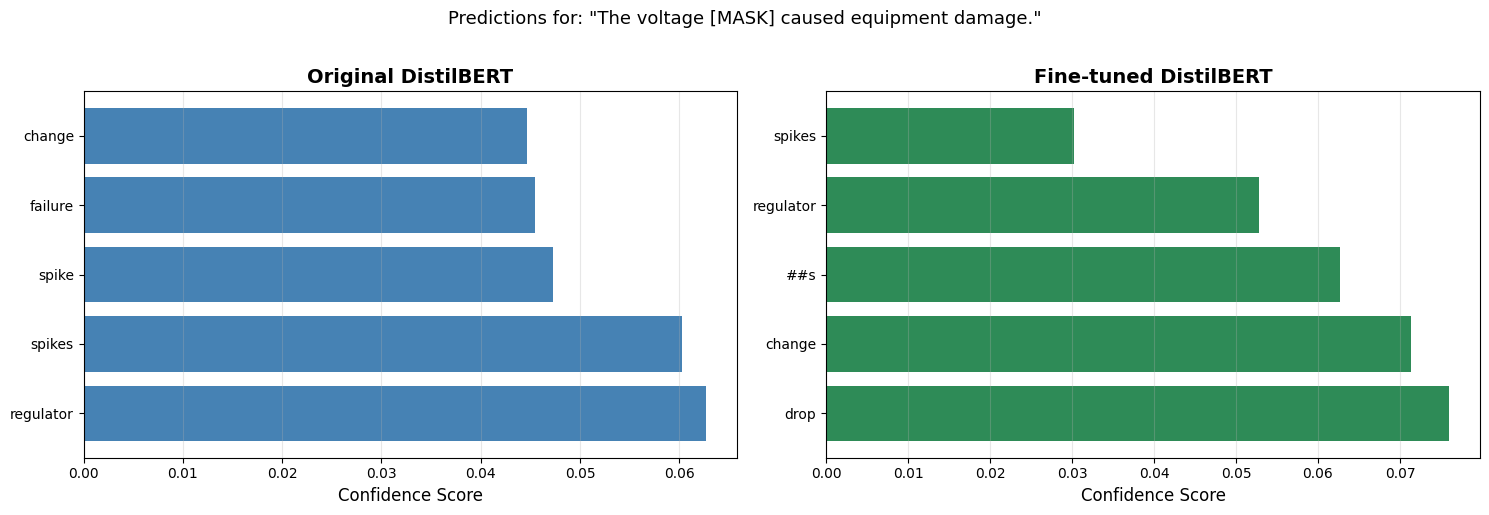

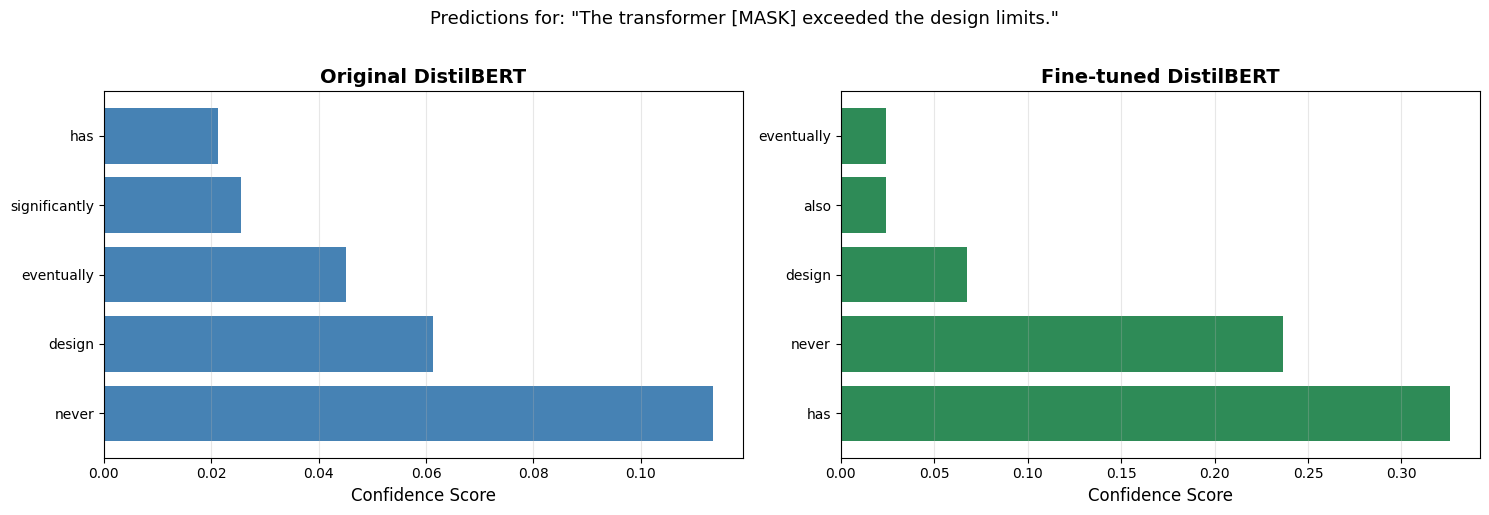

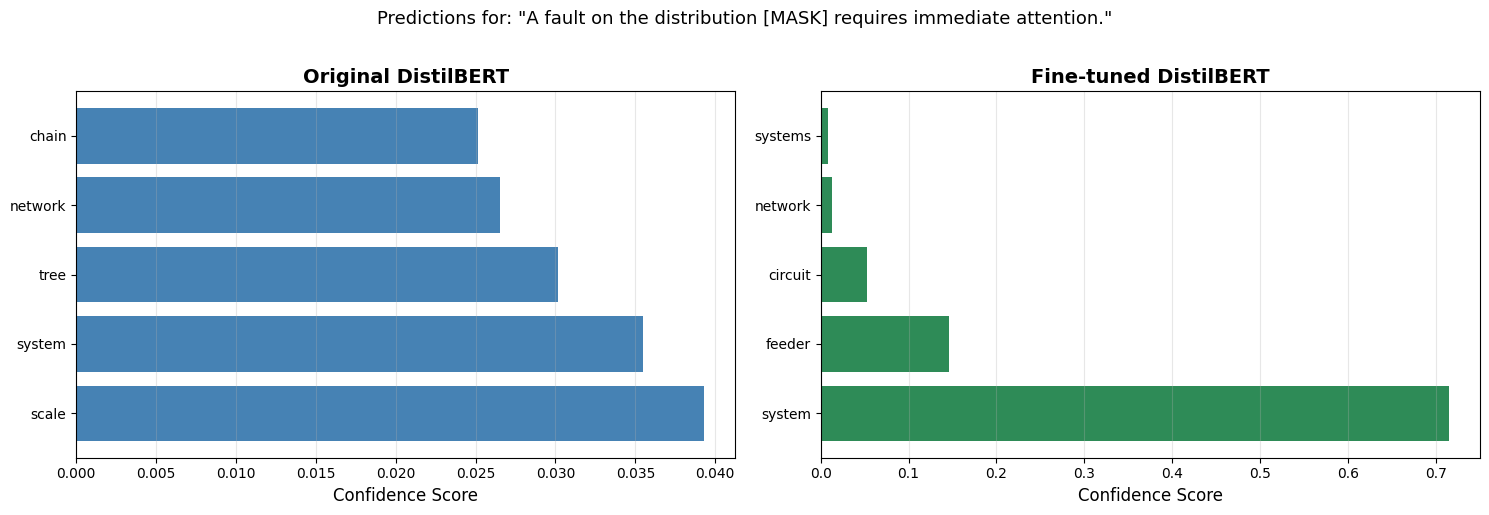

In [16]:
def plot_confidence_comparison(sentence):
    """
    Visualize confidence scores.
    """
    original_preds = fill_mask_original(sentence, top_k=5)
    finetuned_preds = fill_mask_finetuned(sentence, top_k=5)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # Original
    tokens_orig = [p['token_str'].strip() for p in original_preds]
    scores_orig = [p['score'] for p in original_preds]

    ax1.barh(range(len(tokens_orig)), scores_orig, color='steelblue')
    ax1.set_yticks(range(len(tokens_orig)))
    ax1.set_yticklabels(tokens_orig)
    ax1.set_xlabel('Confidence Score', fontsize=12)
    ax1.set_title('Original DistilBERT', fontsize=14, fontweight='bold')
    ax1.grid(axis='x', alpha=0.3)

    # Fine-tuned
    tokens_ft = [p['token_str'].strip() for p in finetuned_preds]
    scores_ft = [p['score'] for p in finetuned_preds]

    ax2.barh(range(len(tokens_ft)), scores_ft, color='seagreen')
    ax2.set_yticks(range(len(tokens_ft)))
    ax2.set_yticklabels(tokens_ft)
    ax2.set_xlabel('Confidence Score', fontsize=12)
    ax2.set_title('Fine-tuned DistilBERT', fontsize=14, fontweight='bold')
    ax2.grid(axis='x', alpha=0.3)

    fig.suptitle(f'Predictions for: "{sentence}"', fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()

print("\n" + "="*80)
print("CONFIDENCE SCORE VISUALIZATIONS")
print("="*80 + "\n")

for sentence in test_sentences[:3]:
    plot_confidence_comparison(sentence)

## 15. Summary Report

In [17]:
print("\n" + "="*80)
print("FINAL SUMMARY REPORT")
print("="*80 + "\n")

print("✅ COMPLETED:")
print("   1. Extracted text with PyMuPDF")
print("   2. Fixed 'anetwork' → 'a network' spacing issues")
print("   3. Created high-quality sentence chunks with NLTK")
print("   4. Fine-tuned with optimized parameters")
print("   5. Evaluated and analyzed predictions")

print("\n📊 RESULTS:")
print(f"   New domain tokens: {len(analysis_results['new_tokens'])}")
print(f"   Confidence change: {analysis_results['avg_confidence_change']:+.2%}")
print(f"   Subword artifacts: {analysis_results['subword_count']}")

if analysis_results['subword_count'] == 0:
    print("\n🎉 SUCCESS! Clean domain adaptation achieved!")
else:
    print(f"\n⚠️  WARNING: {analysis_results['subword_count']} artifacts found")
    print(f"   Artifacts: {analysis_results['subword_tokens']}")
    print("   → Review text extraction and cleaning")

print("\n" + "="*80)


FINAL SUMMARY REPORT

✅ COMPLETED:
   1. Extracted text with PyMuPDF
   2. Fixed 'anetwork' → 'a network' spacing issues
   3. Created high-quality sentence chunks with NLTK
   4. Fine-tuned with optimized parameters
   5. Evaluated and analyzed predictions

📊 RESULTS:
   New domain tokens: 34
   Confidence change: +3.08%
   Subword artifacts: 3

⚠️  WARNING: 3 artifacts found
   Artifacts: ['##ball', '##er', '##s']
   → Review text extraction and cleaning



In [18]:
import shutil
from google.colab import files

output_filename = "distilbert-domain-adapted-final"
shutil.make_archive(output_filename, 'zip', "/content/distilbert-domain-adapted-final")
print(f"Created {output_filename}.zip. Downloading...")
files.download(f"{output_filename}.zip")

Created distilbert-domain-adapted-final.zip. Downloading...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>